In [1]:
from sysdata.config.configdata import Config
config = Config("private.bybit.bybitconfig.yaml")
config

Configuring sim logging


Config with elements: base_currency, forecast_cap, forecast_div_multiplier, forecast_weights, instrument_div_multiplier, instrument_weights, notional_trading_capital, percentage_vol_target, trading_rules

In [2]:
from private.bybit.bybitsystem import bybitsystem
import warnings; warnings.filterwarnings('ignore')
system = bybitsystem()

In [ ]:
system.accounts.portfolio().stats()

In [17]:
acc = system.accounts.portfolio()

print(acc.gross.percent.ann_mean())   # брутто годовые %
print(acc.net.percent.ann_mean())     # нетто
print(acc.costs.percent.ann_mean())   # издержки

acc.percent.stats()            # сводка по %

12.041974911242603
11.70719351579697
-0.3369747220387862


[[('min', '-7.355'),
  ('max', '8.198'),
  ('median', '0.004996'),
  ('mean', '0.04573'),
  ('std', '1.009'),
  ('skew', '0.5165'),
  ('ann_mean', '11.71'),
  ('ann_std', '16.15'),
  ('sharpe', '0.7248'),
  ('sortino', '0.9211'),
  ('avg_drawdown', '-10.06'),
  ('time_in_drawdown', '0.9609'),
  ('calmar', '0.5311'),
  ('avg_return_to_drawdown', '1.164'),
  ('avg_loss', '-0.5368'),
  ('avg_gain', '0.5997'),
  ('gaintolossratio', '1.117'),
  ('profitfactor', '1.176'),
  ('hitrate', '0.5128'),
  ('t_stat', '1.862'),
  ('p_value', '0.06273')],
 ('You can also plot / print:',
  ['rolling_ann_std', 'drawdown', 'curve', 'percent'])]

<Axes: >

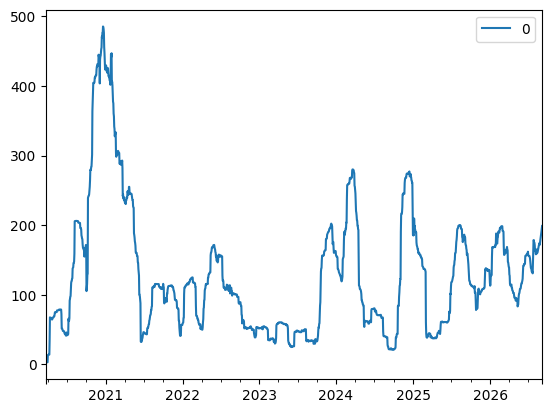

In [17]:
acc.rolling_ann_std().plot()    # скользящий годовой стд

<Axes: >

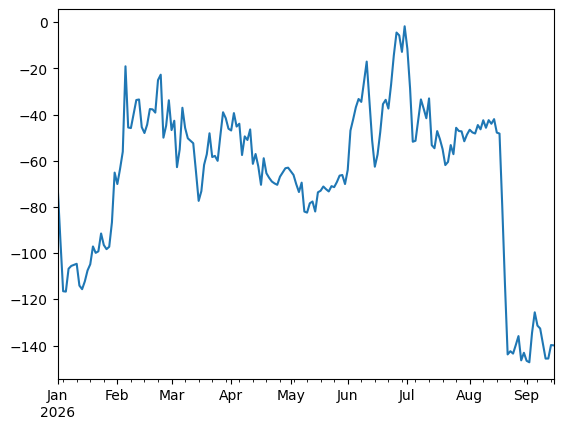

In [18]:
acc.drawdown()['2026'].plot()           # просадка

<Axes: >

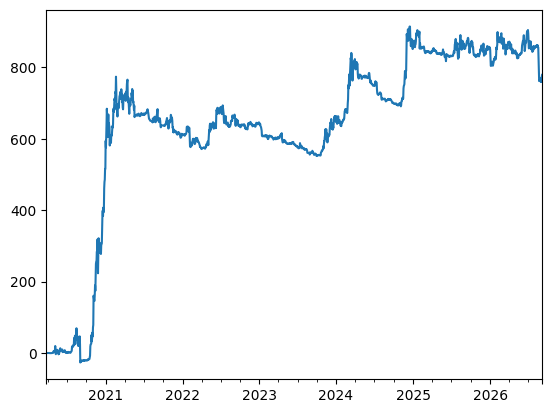

In [15]:
acc.curve().plot()              # кумулятивная кривая

2026-09-15 23:44:03 DEBUG base_system {'stage': 'rawdata', 'instrument_code': 'BTC_BYBIT'} Calculating daily prices for BTC_BYBIT
2026-09-15 23:44:03 INFO bybitFuturesSimData {'component': 'bybitFuturesAdjustedPricesData', 'instrument_code': 'BTC_BYBIT'} Fetching adjusted prices for BTC_BYBIT (ByBit symbol: BTC/USDT:USDT)


<Axes: xlabel='index'>

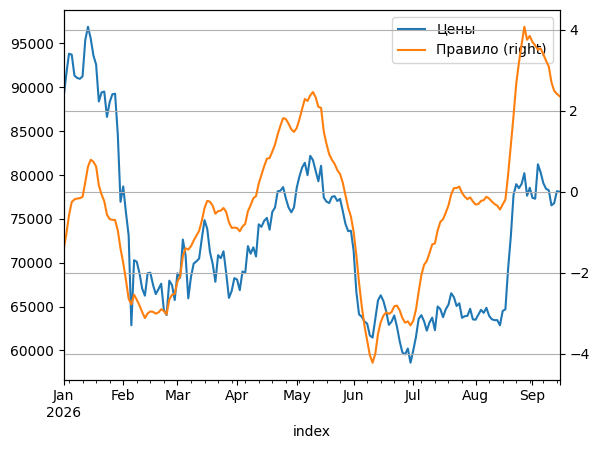

In [15]:
import pandas as pd

# Промежуточные результаты бектеста
s1 = system.rawdata.get_daily_prices("BTC_BYBIT")
s2 = system.rules.get_raw_forecast("BTC_BYBIT", "ewmac8")#['2026'].plot()
# Объединяем по колонкам
df = pd.concat([s1, s2], axis=1)
df.columns = ['Цены', 'Правило']
df.loc['2026'].plot(secondary_y=['Правило'], grid=True)


In [ ]:
# так можно посмотреть все этапы (stages)
print(system)
# по имени системы посмотреть методыы
system.positionSize.methods()

System base_system with .config, .data, and .stages: accounts, portfolio, positionSize, combForecast, forecastScaleCap, rules, rawdata


['annual_cash_vol_target',
 'avg_abs_forecast',
 'comb_forecast_stage',
 'config',
 'get_average_position_at_subsystem_level',
 'get_base_currency',
 'get_block_value',
 'get_buffers_for_subsystem_position',
 'get_combined_forecast',
 'get_daily_cash_vol_target',
 'get_fx_rate',
 'get_instrument_currency_vol',
 'get_instrument_value_vol',
 'get_notional_trading_capital',
 'get_percentage_vol_target',
 'get_price_volatility',
 'get_subsystem_buffers',
 'get_subsystem_position',
 'get_underlying_price',
 'get_vol_target_dict',
 'methods',
 'rawdata_stage',
 'system_init']

In [31]:
# Или вот так еще:
system.rawdata.methods()  ## works for any stage or data

['all_instruments_in_asset_class',
 'annualised_returns_volatility',
 'annualised_roll',
 'config',
 'daily_annualised_roll',
 'daily_denominator_price',
 'daily_returns',
 'daily_returns_volatility',
 'daily_vol_normalised_price_for_asset_class_with_redundant_instrument_code',
 'data_stage',
 'get_cumulative_daily_vol_normalised_returns',
 'get_daily_percentage_returns',
 'get_daily_percentage_volatility',
 'get_daily_prices',
 'get_daily_vol_normalised_returns',
 'get_fx_for_instrument',
 'get_hourly_prices',
 'get_instrument_raw_carry_data',
 'get_natural_frequency_prices',
 'get_raw_cost_data',
 'get_value_of_block_price_move',
 'hourly_returns',
 'instrument_code',
 'instrument_list',
 'median_carry_for_asset_class',
 'methods',
 'normalised_price_for_asset_class',
 'raw_carry',
 'raw_futures_roll',
 'roll_differentials',
 'rolls_per_year',
 'smoothed_carry',
 'system_init',
 'system_with_redundant_instrument_code_passed']